Python works!
3.0.6
(2257, 7)
Index(['id', 'category', 'skills', 'education', 'experience', 'text', 'html'], dtype='str')
0    Word programs (including Excel and Access), EP...
1    Superb sales professional, Store planning and ...
2    Domestic Violence, Sexual Abuse, Rape, Prostit...
3    Accounting, Cashiering, Coaching, Computer tra...
4    Microsoft Suite Proficiency, RightFax Ventura,...
5    Excellent classroom management, Teaching, tuto...
6    Client relations specialist, Team management, ...
7    Peer counseling, customer service, database, d...
8    Cash handling, Shipping and receiving, Careful...
9    Directors Credential, Relationship building, P...
Name: skills, dtype: str
0             BILINGUAL DOMESTIC VIOLENCE ADVOCATE ...
1             CUSTOMER SERVICE ADVOCATE       Summa...
Name: text, dtype: str
['r', 'access', 'excel', 'word', 'sas', 'leadership']
   category                                   extracted_skills
0  ADVOCATE          [r, access, excel, word, sas, le

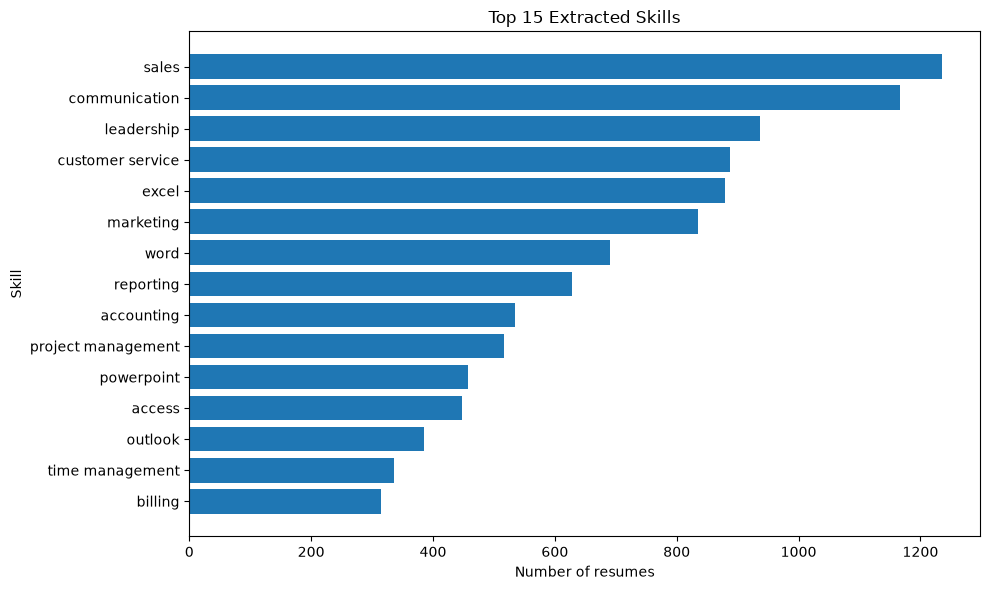

count    2257.000000
mean        5.700930
std         3.000674
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        19.000000
Name: extracted_skills, dtype: float64
Saved successfully!
(2257, 8)
         id  category                                   extracted_skills
0  21614256  ADVOCATE  ['r', 'access', 'excel', 'word', 'sas', 'leade...
1  97405769  ADVOCATE  ['microsoft office', 'customer service', 'sale...
2  95970987  ADVOCATE                                          ['excel']
3  17021141  ADVOCATE  ['access', 'excel', 'word', 'powerpoint', 'acc...
4  15337481  ADVOCATE  ['marketing', 'customer service', 'sales', 'ac...
Resumes without extracted skills: 31
          category                                                                                                                                                                                                                                                                              

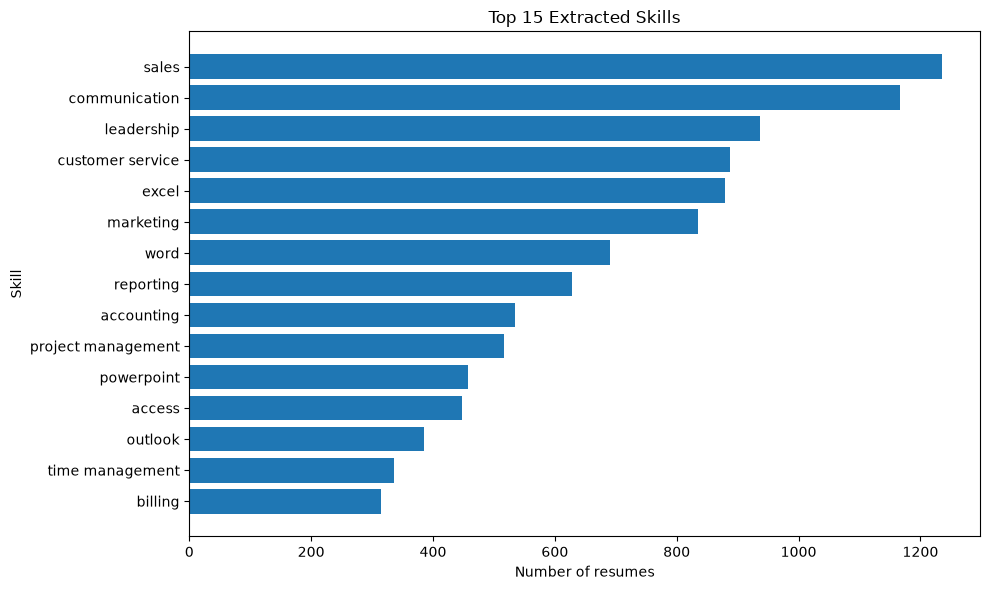

Final CSV saved successfully!
(2257, 8)
         id  category                                   extracted_skills
0  21614256  ADVOCATE  ['r', 'access', 'excel', 'word', 'sas', 'leade...
1  97405769  ADVOCATE  ['microsoft office', 'customer service', 'sale...
2  95970987  ADVOCATE                                          ['excel']
3  17021141  ADVOCATE  ['access', 'excel', 'word', 'powerpoint', 'acc...
4  15337481  ADVOCATE  ['marketing', 'customer service', 'sales', 'ac...


In [1]:
import pandas as pd
import numpy as np

print("Python works!")
print(pd.__version__)



df = pd.read_csv("../data/raw/resumes_real.csv")



print(df.shape)



print(df.columns)




print(df["skills"].head(10))





print(df["text"].head(2))





SKILLS = [
    # Programming
    "python",
    "java",
    "javascript",
    "typescript",
    "c++",
    "c#",
    "r",
    "sql",
    "php",
    "ruby",
    "scala",
    "matlab",

    # Web
    "html",
    "css",
    "react",
    "angular",
    "vue",
    "node.js",
    "django",
    "flask",
    "wordpress",

    # Data / AI
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "machine learning",
    "deep learning",
    "data analysis",
    "data visualization",

    # Databases
    "mysql",
    "postgresql",
    "mongodb",
    "oracle",
    "access",

    # Cloud / DevOps
    "docker",
    "kubernetes",
    "git",
    "github",
    "linux",
    "aws",
    "azure",

    # Microsoft / Office
    "excel",
    "microsoft excel",
    "word",
    "microsoft word",
    "powerpoint",
    "microsoft powerpoint",
    "outlook",
    "publisher",
    "ms office",

    # Business
    "power bi",
    "tableau",
    "sas",
    "crm",

    # Other
    "project management",
    "accounting",
    "marketing",
    "customer service",
    "sales",
    "leadership",
    "communication" ,
    "active listening",
    "curriculum development",
    "group facilitation",
    "crisis counseling",
    "case management",
    "time management",
    "empathy",
    "boundary setting",
    "general computer skills",
    "billing",
    "wound care",
    "discharge planning",
    "coaching",
    "telecommunication",
    "quality assurance",
    "reporting",
    "supervising"
]





import re

def extract_skills(text):
    text = str(text).lower()

    found = []

    for skill in SKILLS:
        pattern = r"\b" + re.escape(skill) + r"\b"

        if re.search(pattern, text):
            found.append(skill)

    return found






print(extract_skills(df["text"].iloc[0]))






df["extracted_skills"] = df["text"].apply(extract_skills)





print(df[["category", "extracted_skills"]].head(10))





print(df[["skills", "extracted_skills"]].head(10).to_string())




SKILL_NORMALIZATION = {
    "microsoft excel": "excel",
    "microsoft word": "word",
    "microsoft powerpoint": "powerpoint",
    "ms office": "microsoft office",
    "power bi": "power bi",
    "node.js": "nodejs",
    "c++": "cpp",
    "c#": "csharp"
}



def normalize_extracted_skills(skills):
    normalized = []

    for skill in skills:
        skill = SKILL_NORMALIZATION.get(skill, skill)

        if skill not in normalized:
            normalized.append(skill)

    return normalized






df["extracted_skills"] = df["extracted_skills"].apply(
    normalize_extracted_skills
)




print(df[["category", "extracted_skills"]].head(10).to_string())





total_resumes = len(df)

with_skills = (df["extracted_skills"].apply(len) > 0).sum()

without_skills = total_resumes - with_skills

print("Total resumes:", total_resumes)
print("Resumes with extracted skills:", with_skills)
print("Resumes without extracted skills:", without_skills)




from collections import Counter

all_extracted_skills = []

for skills in df["extracted_skills"]:
    all_extracted_skills.extend(skills)

skill_counts = Counter(all_extracted_skills)

print(skill_counts.most_common(20))




import matplotlib.pyplot as plt

top_skills = skill_counts.most_common(15)

skills = [skill for skill, count in top_skills]
counts = [count for skill, count in top_skills]

plt.figure(figsize=(10, 6))
plt.barh(skills[::-1], counts[::-1])
plt.xlabel("Number of resumes")
plt.ylabel("Skill")
plt.title("Top 15 Extracted Skills")
plt.tight_layout()
plt.show()





print(df["extracted_skills"].apply(len).describe())




import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/resumes_with_extracted_skills.csv",
    index=False
)

print("Saved successfully!")





check_df = pd.read_csv(
    "../data/processed/resumes_with_extracted_skills.csv"
)

print(check_df.shape)
print(check_df[["id", "category", "extracted_skills"]].head())




no_skills = df[df["extracted_skills"].apply(len) == 0]

print("Resumes without extracted skills:", len(no_skills))
print(no_skills[["category", "text"]].head(3).to_string())




df["extracted_skills"] = df["text"].apply(extract_skills)

df["extracted_skills"] = df["extracted_skills"].apply(
    normalize_extracted_skills
)

print(df[["category", "extracted_skills"]].head(10))




print("Total resumes:", len(df))

with_skills = (df["extracted_skills"].apply(len) > 0).sum()
without_skills = (df["extracted_skills"].apply(len) == 0).sum()

print("Resumes with extracted skills:", with_skills)
print("Resumes without extracted skills:", without_skills)



from collections import Counter

all_extracted_skills = []

for skills in df["extracted_skills"]:
    all_extracted_skills.extend(skills)

skill_counts = Counter(all_extracted_skills)

print(skill_counts.most_common(20))



import matplotlib.pyplot as plt

top_skills = skill_counts.most_common(15)

skills = [skill for skill, count in top_skills]
counts = [count for skill, count in top_skills]

plt.figure(figsize=(10, 6))
plt.barh(skills[::-1], counts[::-1])
plt.xlabel("Number of resumes")
plt.ylabel("Skill")
plt.title("Top 15 Extracted Skills")
plt.tight_layout()
plt.show()




df.to_csv(
    "../data/processed/resumes_with_extracted_skills.csv",
    index=False
)

print("Final CSV saved successfully!")




check_df = pd.read_csv(
    "../data/processed/resumes_with_extracted_skills.csv"
)

print(check_df.shape)
print(check_df[["id", "category", "extracted_skills"]].head())